# Reconnaissance de Chiffres Manuscrits

L'objectif de ce projet est de construire des modèles capables de reconnaître automatiquement des chiffres manuscrits (0 à 9) à partir d'images numériques. Nous allons suivre une démarche complète : exploration des données, prétraitement, réduction de dimension par ACP, entraînement de plusieurs classifieurs, évaluation et optimisation des hyperparamètres.

---
## 1. Imports et Chargement des Données

On commence par importer toutes les bibliothèques nécessaires au projet. `scikit-learn` fournit le dataset et tous les outils de machine learning. `pandas` et `numpy` servent à manipuler les données, `matplotlib` et `seaborn` à les visualiser.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
print("Imports effectues avec succes.")

Imports effectues avec succes.


Le dataset Digits de scikit-learn contient 1797 images de chiffres manuscrits. Chaque image est représentée sous forme d'une grille 8x8 pixels, où chaque pixel a une valeur d'intensité entre 0 (blanc) et 16 (noir). La variable `X` contient les images aplaties en vecteurs de 64 valeurs, et `y` contient le label correspondant (le chiffre réel de 0 à 9).

In [2]:
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

print(f"Forme de X : {X.shape}  ->  {X.shape[0]} images, {X.shape[1]} pixels chacune")
print(f"Forme de y : {y.shape}  ->  {y.shape[0]} labels")
print(f"Classes disponibles : {np.unique(y)}")

Forme de X : (1797, 64)  ->  1797 images, 64 pixels chacune
Forme de y : (1797,)  ->  1797 labels
Classes disponibles : [0 1 2 3 4 5 6 7 8 9]


---
## 2. Exploration des Données

### 2.1 Visualisation des images

Avant toute modélisation, il est essentiel de regarder les données brutes. On affiche un exemple de chaque chiffre pour comprendre ce à quoi ressemblent les images. Chaque image est une grille 8x8 pixels, ce qui est très basse résolution mais suffisant pour distinguer les chiffres. On affiche aussi plusieurs exemples du même chiffre pour visualiser la variabilité d'écriture.

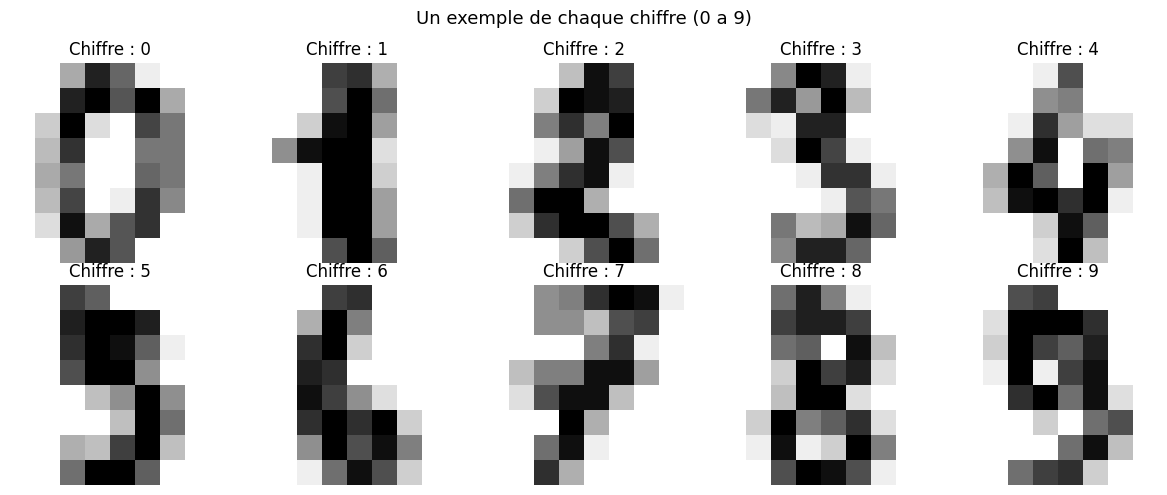

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Un exemple de chaque chiffre (0 a 9)", fontsize=13)
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y == digit)[0][0]
    ax.imshow(images[idx], cmap='gray_r')
    ax.set_title(f"Chiffre : {digit}")
    ax.axis('off')
plt.tight_layout()
plt.show()

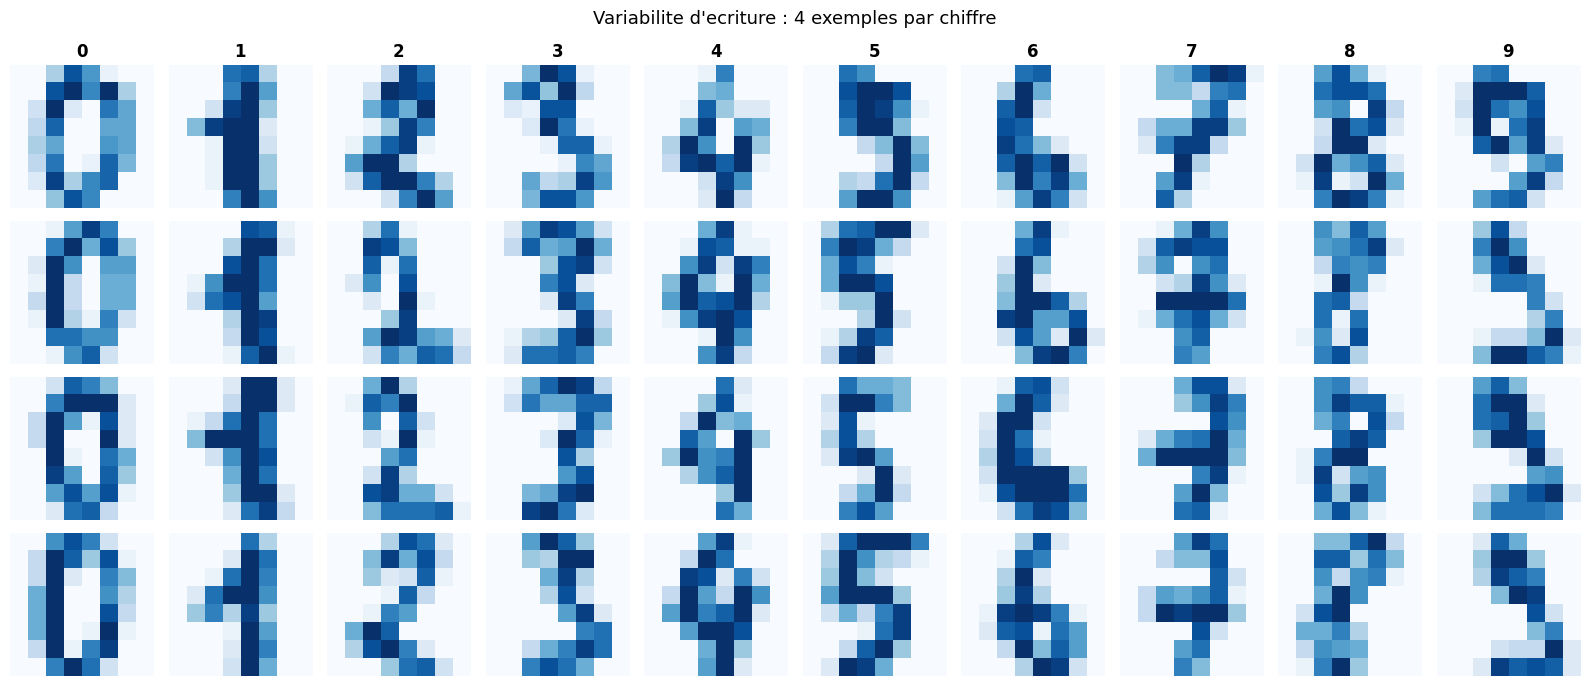

In [4]:
# Plusieurs exemples d'un meme chiffre pour voir la variabilite d'ecriture
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
fig.suptitle("Variabilite d'ecriture : 4 exemples par chiffre", fontsize=13)
for digit in range(10):
    indices = np.where(y == digit)[0][:4]
    for row, idx in enumerate(indices):
        ax = axes[row, digit]
        ax.imshow(images[idx], cmap='Blues', interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Distribution des classes

On vérifie si le dataset est équilibré, c'est-à-dire si chaque chiffre est représenté par un nombre similaire d'exemples. Un déséquilibre important biaiserait les modèles en faveur des classes majoritaires et rendrait les métriques comme l'accuracy trompeuses.

 Chiffre  Nombre echantillons  Proportion (%)
       0                  178            9.91
       1                  182           10.13
       2                  177            9.85
       3                  183           10.18
       4                  181           10.07
       5                  182           10.13
       6                  181           10.07
       7                  179            9.96
       8                  174            9.68
       9                  180           10.02

Desequilibre max : 9 echantillons
Dataset quasi-equilibre : chaque classe est representee de maniere similaire.


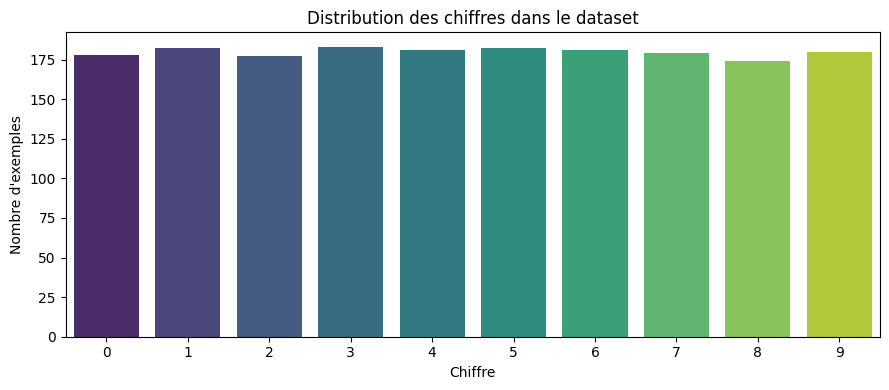

In [5]:
class_counts = pd.Series(y).value_counts().sort_index()

class_df = pd.DataFrame({
    'Chiffre': class_counts.index,
    'Nombre echantillons': class_counts.values,
    'Proportion (%)': (class_counts.values / len(y) * 100).round(2)
})
print(class_df.to_string(index=False))
print(f"\nDesequilibre max : {class_counts.max() - class_counts.min()} echantillons")
print("Dataset quasi-equilibre : chaque classe est representee de maniere similaire.")

plt.figure(figsize=(9, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution des chiffres dans le dataset")
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'exemples")
plt.tight_layout()
plt.show()

### 2.3 Statistiques descriptives sur les pixels

On examine les statistiques de base des valeurs de pixels. Les pixels varient entre 0 et 16. La grande proportion de pixels à 0 indique que les images ont beaucoup d'espace blanc (fond), ce qui est cohérent : seuls quelques pixels par image forment réellement le chiffre. L'image moyenne de chaque chiffre révèle les zones caractéristiques utilisées pour le distinguer.

In [6]:
print("=== Statistiques sur l'intensite des pixels ===")
print(f"Valeur maximale : {X.max()}")
print(f"Valeur minimale : {X.min()}")
print(f"Moyenne globale : {X.mean():.2f}")
print(f"Ecart-type      : {X.std():.2f}")

feature_names = [f'pixel_{i}' for i in range(64)]
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y

desc = df.drop('label', axis=1).describe()
print("\nStatistiques par pixel (extrait des 10 premiers pixels) :")
print(desc.T[['mean','std','min','25%','50%','75%','max']].round(2).head(10).to_string())

=== Statistiques sur l'intensite des pixels ===
Valeur maximale : 16.0
Valeur minimale : 0.0
Moyenne globale : 4.88
Ecart-type      : 6.02

Statistiques par pixel (extrait des 10 premiers pixels) :
          mean   std  min   25%   50%   75%   max
pixel_0   0.00  0.00  0.0   0.0   0.0   0.0   0.0
pixel_1   0.30  0.91  0.0   0.0   0.0   0.0   8.0
pixel_2   5.20  4.75  0.0   1.0   4.0   9.0  16.0
pixel_3  11.84  4.25  0.0  10.0  13.0  15.0  16.0
pixel_4  11.85  4.29  0.0  10.0  13.0  15.0  16.0
pixel_5   5.78  5.67  0.0   0.0   4.0  11.0  16.0
pixel_6   1.36  3.33  0.0   0.0   0.0   0.0  16.0
pixel_7   0.13  1.04  0.0   0.0   0.0   0.0  15.0
pixel_8   0.01  0.09  0.0   0.0   0.0   0.0   2.0
pixel_9   1.99  3.20  0.0   0.0   0.0   3.0  16.0


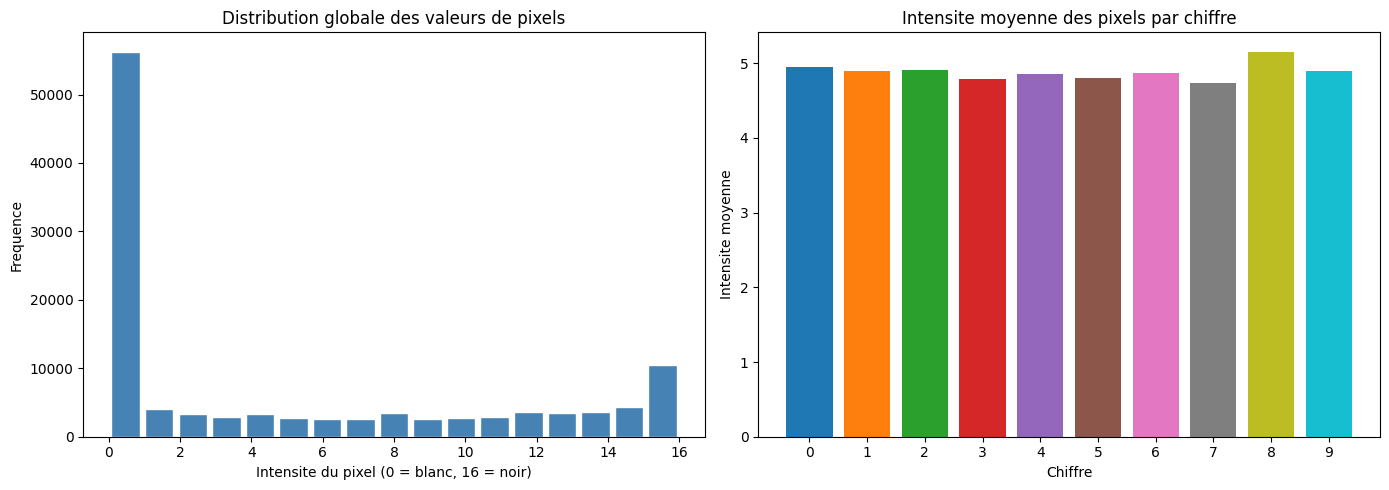

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(X.flatten(), bins=17, color='steelblue', edgecolor='white', rwidth=0.85)
axes[0].set_title('Distribution globale des valeurs de pixels')
axes[0].set_xlabel('Intensite du pixel (0 = blanc, 16 = noir)')
axes[0].set_ylabel('Frequence')

means_by_class = df.groupby('label').mean().mean(axis=1)
axes[1].bar(means_by_class.index, means_by_class.values,
            color=sns.color_palette('tab10', 10))
axes[1].set_title('Intensite moyenne des pixels par chiffre')
axes[1].set_xlabel('Chiffre')
axes[1].set_ylabel('Intensite moyenne')
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

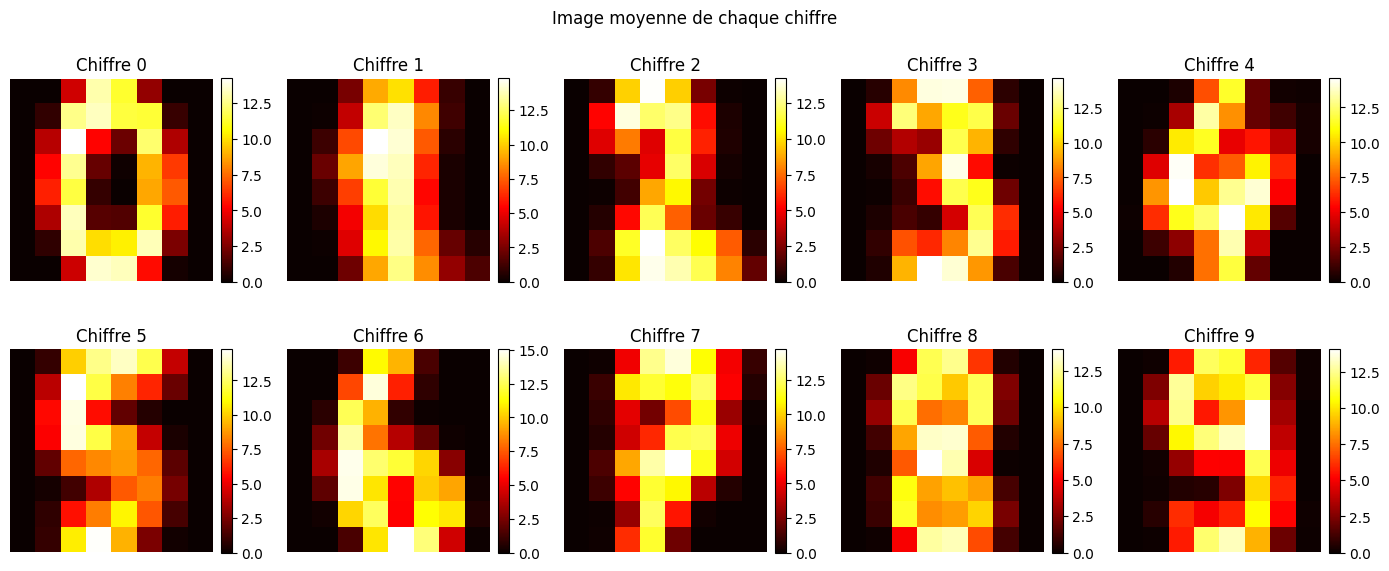

In [8]:
# Image moyenne de chaque chiffre : on calcule le pixel moyen sur tous les exemples
# d'un meme chiffre. Cela revele les zones caracteristiques de chaque classe.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Image moyenne de chaque chiffre", fontsize=12)
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    mean_image = X[y == digit].mean(axis=0).reshape(8, 8)
    im = ax.imshow(mean_image, cmap='hot', interpolation='nearest')
    ax.set_title(f'Chiffre {digit}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

---
## 3. Prétraitement

### 3.1 Division Train / Test

On divise le dataset en un ensemble d'entraînement (80%) et un ensemble de test (20%). L'argument `stratify=y` garantit que chaque chiffre est représenté dans les mêmes proportions dans les deux ensembles. Cette séparation est fondamentale : le modèle ne verra jamais les données de test pendant l'entraînement, ce qui permet une évaluation honnête de sa capacité à généraliser.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Ensemble d'entrainement : {X_train.shape[0]} echantillons")
print(f"Ensemble de test        : {X_test.shape[0]} echantillons")

Ensemble d'entrainement : 1437 echantillons
Ensemble de test        : 360 echantillons


### 3.2 Normalisation (StandardScaler)

La normalisation centre chaque feature à une moyenne de 0 et un écart-type de 1. C'est une étape cruciale pour les algorithmes sensibles à l'échelle des données comme le SVM et le k-NN : sans normalisation, un pixel avec des valeurs élevées dominerait les calculs de distance.

Règle importante : le `StandardScaler` est ajusté (`fit`) uniquement sur les données d'entraînement, puis appliqué (`transform`) sur les deux ensembles. Cela évite toute fuite d'information du test vers l'entraînement.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform sur le train uniquement
X_test_scaled  = scaler.transform(X_test)         # transform uniquement sur le test

print(f"Avant normalisation -> Moyenne : {X_train.mean():.2f}, Std : {X_train.std():.2f}")
print(f"Apres normalisation -> Moyenne : {X_train_scaled.mean():.4f}, Std : {X_train_scaled.std():.4f}")

Avant normalisation -> Moyenne : 4.90, Std : 6.02
Apres normalisation -> Moyenne : 0.0000, Std : 0.9763


### 3.3 Réduction de Dimension par ACP (PCA)

L'Analyse en Composantes Principales (ACP) transforme les 64 pixels originaux en de nouvelles variables appelées composantes principales. Ces composantes sont ordonnées par quantité d'information capturée : la première composante capture le plus de variance, la deuxième en capture le plus parmi celles qui restent, et ainsi de suite.

On commence par ajuster une ACP sans limite de composantes pour visualiser deux courbes :
- La variance expliquée par chaque composante : c'est la méthode du coude, on cherche le point à partir duquel la courbe s'aplatit fortement.
- La variance expliquée cumulée : elle monte rapidement puis ralentit. Le seuil de 95% donne un bon compromis entre réduction et conservation de l'information.

Nombre de composantes pour conserver 95% de la variance : 40 (sur 64)


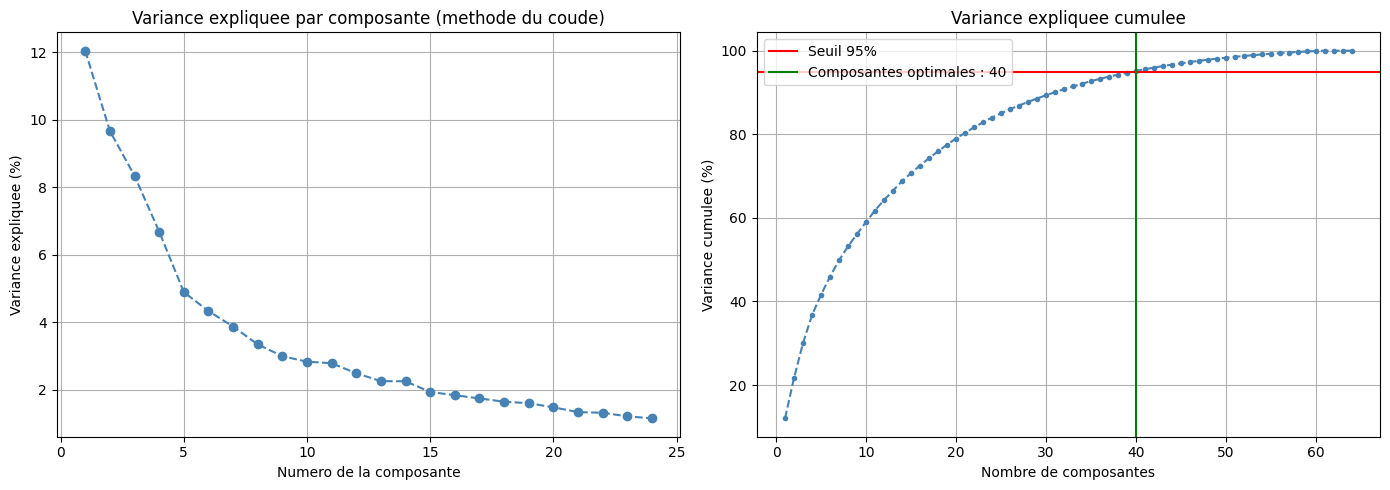

In [11]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

variance_par_composante = pca_full.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_par_composante)

optimal_components = np.argmax(variance_cumulee >= 0.95) + 1
print(f"Nombre de composantes pour conserver 95% de la variance : {optimal_components} (sur 64)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Methode du coude : variance par composante
axes[0].plot(range(1, 25), variance_par_composante[:24] * 100,
             marker='o', linestyle='--', color='steelblue')
axes[0].set_title('Variance expliquee par composante (methode du coude)')
axes[0].set_xlabel('Numero de la composante')
axes[0].set_ylabel('Variance expliquee (%)')
axes[0].grid(True)

# Variance cumulee
axes[1].plot(range(1, len(variance_cumulee) + 1), variance_cumulee * 100,
             marker='o', linestyle='--', color='steelblue', markersize=3)
axes[1].axhline(y=95, color='red', linestyle='-', label='Seuil 95%')
axes[1].axvline(x=optimal_components, color='green', linestyle='-',
                label=f'Composantes optimales : {optimal_components}')
axes[1].set_title('Variance expliquee cumulee')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulee (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Application de l'ACP en conservant 95% de la variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Dimensions originales      : {X_train_scaled.shape[1]} features")
print(f"Dimensions apres ACP (95%) : {X_train_pca.shape[1]} composantes")
print(f"Reduction de {X_train_scaled.shape[1]} a {X_train_pca.shape[1]} dimensions.")

Dimensions originales      : 64 features
Dimensions apres ACP (95%) : 40 composantes
Reduction de 64 a 40 dimensions.


---
## 4. Modélisation

Nous allons entraîner quatre classifieurs différents et comparer leurs performances avec et sans réduction de dimension par ACP. Pour chaque modèle, on entraîne deux versions : une sur les 64 pixels normalisés (données brutes) et une sur les composantes principales issues de l'ACP. Cette comparaison permet de voir si la réduction de dimension aide, nuit ou n'a pas d'effet selon le type d'algorithme.

In [13]:
def evaluer_modele(modele, X_tr, y_tr, X_te, y_te, nom):
    """
    Entraine un modele, calcule l'accuracy sur train et test,
    affiche les resultats et retourne un dictionnaire.
    """
    modele.fit(X_tr, y_tr)
    acc_train = accuracy_score(y_tr, modele.predict(X_tr))
    acc_test  = accuracy_score(y_te, modele.predict(X_te))
    print(f"  {nom:<40} Train: {acc_train:.4f}   Test: {acc_test:.4f}")
    return {'modele': modele, 'nom': nom, 'train': acc_train, 'test': acc_test}

### 4.1 K-Nearest Neighbors (k-NN)

Le k-NN est un algorithme de classification basé sur la similarité : pour classer une nouvelle image, il cherche les k images les plus proches dans l'espace des features (selon la distance euclidienne) et vote à la majorité. C'est un algorithme simple et intuitif, mais sensible à la dimensionnalité : en haute dimension, toutes les distances tendent à devenir similaires, ce qui rend les voisins moins pertinents. L'ACP peut donc particulièrement aider le k-NN en réduisant cet effet.

In [14]:
print("=== K-Nearest Neighbors ===")
print(f"{'Modele':<40} {'Train':>8}   {'Test':>8}")
print("-" * 65)

r_knn_raw = evaluer_modele(KNeighborsClassifier(n_neighbors=5),
                            X_train_scaled, y_train, X_test_scaled, y_test,
                            "k-NN (k=5) - pixels bruts")

r_knn_pca = evaluer_modele(KNeighborsClassifier(n_neighbors=5),
                            X_train_pca, y_train, X_test_pca, y_test,
                            "k-NN (k=5) - ACP")

=== K-Nearest Neighbors ===
Modele                                      Train       Test
-----------------------------------------------------------------
  k-NN (k=5) - pixels bruts                Train: 0.9840   Test: 0.9639
  k-NN (k=5) - ACP                         Train: 0.9854   Test: 0.9722


### 4.2 Support Vector Classifier (SVC)

Le SVM cherche l'hyperplan qui sépare les classes avec la marge maximale. Avec le noyau RBF (Radial Basis Function), il peut tracer des frontières de décision non linéaires, ce qui est adapté à la reconnaissance d'images. Le paramètre `C` contrôle le compromis entre une marge large et une bonne classification des points d'entraînement ; `gamma` contrôle l'influence de chaque point. Le SVM est souvent l'un des meilleurs algorithmes pour ce type de problème.

In [15]:
print("=== Support Vector Classifier ===")
print(f"{'Modele':<40} {'Train':>8}   {'Test':>8}")
print("-" * 65)

r_svc_raw = evaluer_modele(SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
                            X_train_scaled, y_train, X_test_scaled, y_test,
                            "SVC (RBF) - pixels bruts")

r_svc_pca = evaluer_modele(SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
                            X_train_pca, y_train, X_test_pca, y_test,
                            "SVC (RBF) - ACP")

=== Support Vector Classifier ===
Modele                                      Train       Test
-----------------------------------------------------------------
  SVC (RBF) - pixels bruts                 Train: 0.9972   Test: 0.9750
  SVC (RBF) - ACP                          Train: 0.9972   Test: 0.9778


### 4.3 Random Forest

Le Random Forest construit un grand nombre d'arbres de décision en parallèle, chacun entraîné sur un sous-échantillon aléatoire des données et des features. La prédiction finale est la classe majoritaire parmi tous les votes des arbres. Cette approche réduit considérablement le sur-apprentissage par rapport à un seul arbre, et produit généralement de bonnes performances sans beaucoup de réglage. Le Random Forest étant naturellement robuste à la haute dimensionnalité, l'ACP peut être moins utile pour lui.

In [16]:
print("=== Random Forest ===")
print(f"{'Modele':<40} {'Train':>8}   {'Test':>8}")
print("-" * 65)

r_rf_raw = evaluer_modele(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
                           X_train_scaled, y_train, X_test_scaled, y_test,
                           "Random Forest (100 arbres) - pixels bruts")

r_rf_pca = evaluer_modele(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
                           X_train_pca, y_train, X_test_pca, y_test,
                           "Random Forest (100 arbres) - ACP")

=== Random Forest ===
Modele                                      Train       Test
-----------------------------------------------------------------
  Random Forest (100 arbres) - pixels bruts Train: 1.0000   Test: 0.9639
  Random Forest (100 arbres) - ACP         Train: 1.0000   Test: 0.9556


### 4.4 Arbre de Décision

Un arbre de décision apprend une suite de règles de type "si pixel_X > seuil alors...". C'est l'algorithme de base dont le Random Forest est composé. Seul, il tend à mémoriser intégralement les données d'entraînement (sur-apprentissage fort : accuracy train proche de 1.0), ce qui le rend peu robuste sur de nouvelles données. On l'inclut ici comme référence pour comprendre pourquoi agréger plusieurs arbres dans un Random Forest améliore la généralisation.

In [17]:
print("=== Arbre de Decision ===")
print(f"{'Modele':<40} {'Train':>8}   {'Test':>8}")
print("-" * 65)

r_dt_raw = evaluer_modele(DecisionTreeClassifier(random_state=RANDOM_STATE),
                           X_train_scaled, y_train, X_test_scaled, y_test,
                           "Arbre de Decision - pixels bruts")

r_dt_pca = evaluer_modele(DecisionTreeClassifier(random_state=RANDOM_STATE),
                           X_train_pca, y_train, X_test_pca, y_test,
                           "Arbre de Decision - ACP")

=== Arbre de Decision ===
Modele                                      Train       Test
-----------------------------------------------------------------
  Arbre de Decision - pixels bruts         Train: 1.0000   Test: 0.8167
  Arbre de Decision - ACP                  Train: 1.0000   Test: 0.8250


### 4.5 Tableau Comparatif

In [18]:
tous_resultats = [r_knn_raw, r_knn_pca, r_svc_raw, r_svc_pca,
                  r_rf_raw,  r_rf_pca,  r_dt_raw,  r_dt_pca]

df_resultats = pd.DataFrame([
    {'Modele': r['nom'],
     'Acc. Train': round(r['train'], 4),
     'Acc. Test':  round(r['test'],  4),
     'Ecart (surapprentissage)': round(r['train'] - r['test'], 4)}
    for r in tous_resultats
])
print(df_resultats.to_string(index=False))

                                   Modele  Acc. Train  Acc. Test  Ecart (surapprentissage)
                k-NN (k=5) - pixels bruts      0.9840     0.9639                    0.0201
                         k-NN (k=5) - ACP      0.9854     0.9722                    0.0132
                 SVC (RBF) - pixels bruts      0.9972     0.9750                    0.0222
                          SVC (RBF) - ACP      0.9972     0.9778                    0.0194
Random Forest (100 arbres) - pixels bruts      1.0000     0.9639                    0.0361
         Random Forest (100 arbres) - ACP      1.0000     0.9556                    0.0444
         Arbre de Decision - pixels bruts      1.0000     0.8167                    0.1833
                  Arbre de Decision - ACP      1.0000     0.8250                    0.1750


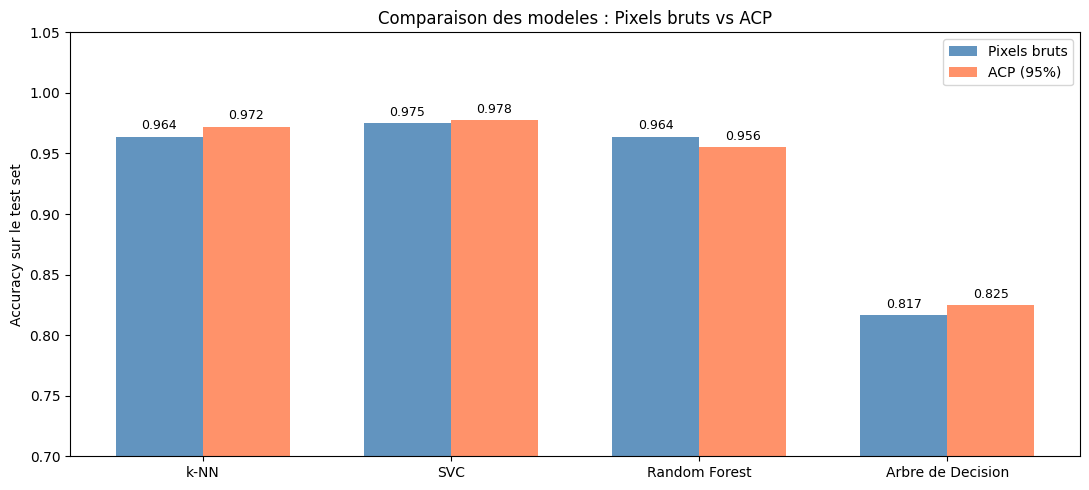

In [19]:
modeles_noms = ['k-NN', 'SVC', 'Random Forest', 'Arbre de Decision']
acc_brut = [r_knn_raw['test'], r_svc_raw['test'], r_rf_raw['test'], r_dt_raw['test']]
acc_pca  = [r_knn_pca['test'], r_svc_pca['test'], r_rf_pca['test'], r_dt_pca['test']]

x = np.arange(len(modeles_noms))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, acc_brut, width, label='Pixels bruts', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, acc_pca,  width, label='ACP (95%)',    color='coral',     alpha=0.85)
ax.set_ylabel('Accuracy sur le test set')
ax.set_title('Comparaison des modeles : Pixels bruts vs ACP')
ax.set_xticks(x)
ax.set_xticklabels(modeles_noms)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Évaluation des Performances

### 5.1 Matrice de Confusion

La matrice de confusion est un tableau qui montre, pour chaque chiffre réel (lignes), combien de fois le modèle l'a prédit comme chaque chiffre possible (colonnes). La diagonale principale représente les bonnes prédictions. Les cases hors diagonale représentent les erreurs : par exemple, si la case (ligne 3, colonne 8) est non nulle, cela signifie que des images du chiffre 3 ont été classées comme 8. C'est un outil bien plus informatif que l'accuracy seule, car il révèle quelles classes sont confondues entre elles.

La version normalisée divise chaque ligne par le nombre total d'exemples de la classe : elle montre le rappel (taux de bonne détection) pour chaque chiffre.

Meilleur modele : SVC (RBF) - pixels bruts
Accuracy test   : 0.9750


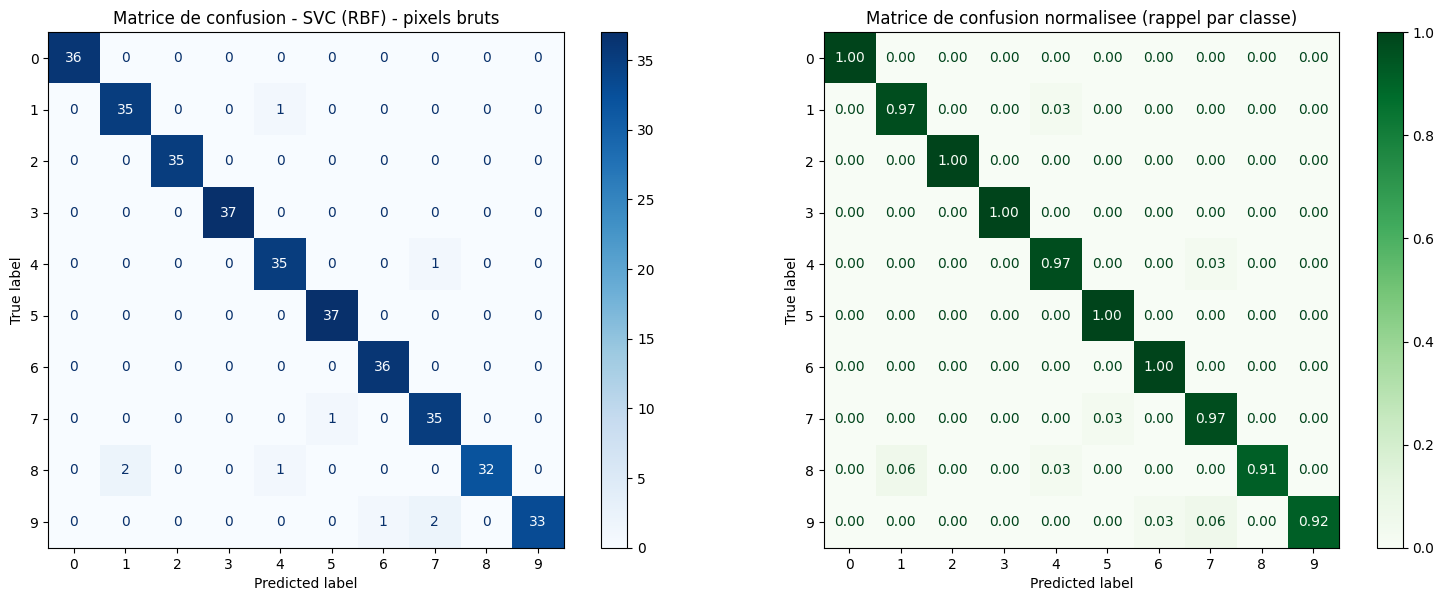

In [20]:
# On selectionne le modele avec la meilleure accuracy test sur pixels bruts
meilleur = max([r_knn_raw, r_svc_raw, r_rf_raw, r_dt_raw], key=lambda r: r['test'])
print(f"Meilleur modele : {meilleur['nom']}")
print(f"Accuracy test   : {meilleur['test']:.4f}")

y_pred = meilleur['modele'].predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(
    ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title(f'Matrice de confusion - {meilleur["nom"]}')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=range(10)).plot(
    ax=axes[1], colorbar=True, cmap='Greens', values_format='.2f')
axes[1].set_title('Matrice de confusion normalisee (rappel par classe)')

plt.tight_layout()
plt.show()

In [21]:
print("Rapport de classification detaille :")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

print("Confusions les plus frequentes (hors diagonale) :")
confusion_pairs = [(cm[i, j], i, j)
                   for i in range(10) for j in range(10)
                   if i != j and cm[i, j] > 0]
confusion_pairs.sort(reverse=True)
for count, true_l, pred_l in confusion_pairs[:8]:
    print(f"  Chiffre reel {true_l} predit comme {pred_l} : {count} fois")

Rapport de classification detaille :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360

Confusions les plus frequentes (hors diagonale) :
  Chiffre reel 9 predit comme 7 : 2 fois
  Chiffre reel 8 predit comme 1 : 2 fois
  Chiffre reel 9 predit comme 6 : 1 fois
  Chiffre reel 8 predit comme 4

Nombre d'erreurs : 9 sur 360 exemples de test


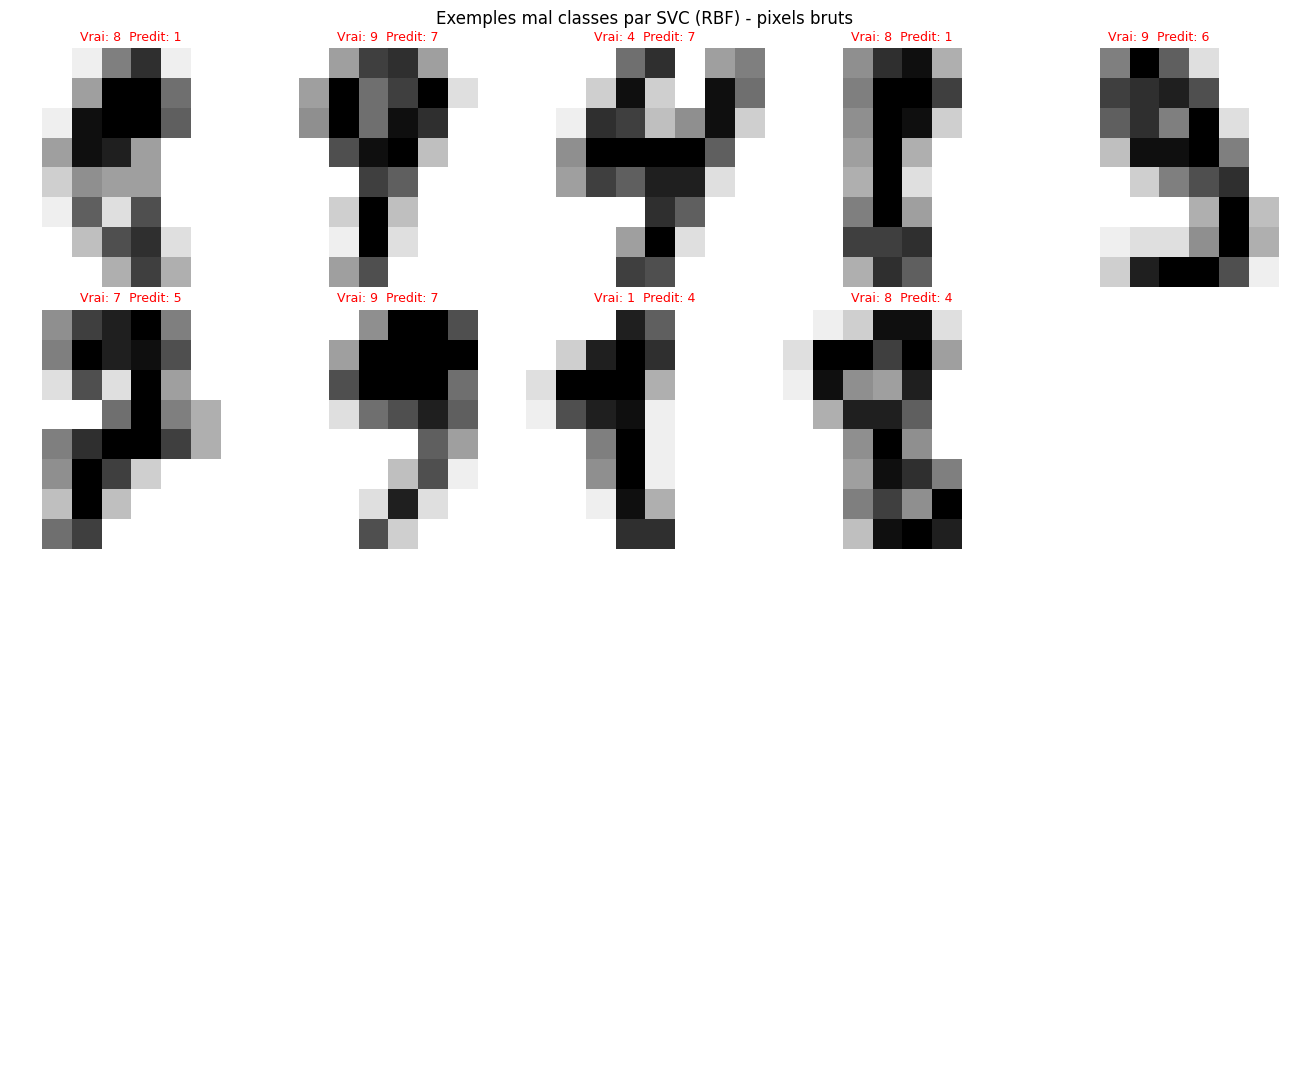

In [22]:
# Exemples d'images mal classees
errors = np.where(y_pred != y_test)[0]
print(f"Nombre d'erreurs : {len(errors)} sur {len(y_test)} exemples de test")

n_show = min(20, len(errors))
fig, axes = plt.subplots(4, 5, figsize=(13, 11))
fig.suptitle(f'Exemples mal classes par {meilleur["nom"]}', fontsize=12)
for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = errors[i]
        ax.imshow(X_test[idx].reshape(8, 8), cmap='gray_r', interpolation='nearest')
        ax.set_title(f'Vrai: {y_test[idx]}  Predit: {y_pred[idx]}',
                     fontsize=9, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 5.2 Validation Croisée

Un seul split train/test peut donner une estimation biaisée de la performance : si par malchance le test set est particulièrement facile ou difficile, le score sera trompeur. La validation croisée stratifiée à k plis résout ce problème : on divise les données en k sous-ensembles, on entraîne k modèles en utilisant chaque fois un sous-ensemble différent comme ensemble de validation, puis on moyenne les k scores obtenus. L'écart-type des scores mesure la stabilité du modèle. L'intervalle de confiance à 95% donne une fourchette fiable de la performance réelle attendue sur de nouvelles données.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modeles_cv = {
    'k-NN (k=5)':        KNeighborsClassifier(n_neighbors=5),
    'SVC (RBF)':         SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Arbre de Decision': DecisionTreeClassifier(random_state=RANDOM_STATE)
}

print("Validation croisee 5-fold (sur pixels bruts normalises) :")
print(f"{'Modele':<25} {'Moyenne':>10} {'Std':>8} {'IC 95%':>22}")
print("-" * 70)

cv_scores = {}
for nom, modele in modeles_cv.items():
    scores = cross_val_score(modele, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_scores[nom] = scores
    ic_low  = scores.mean() - 1.96 * scores.std()
    ic_high = scores.mean() + 1.96 * scores.std()
    print(f"  {nom:<23} {scores.mean():>10.4f} {scores.std():>8.4f}   [{ic_low:.4f}, {ic_high:.4f}]")

Validation croisee 5-fold (sur pixels bruts normalises) :
Modele                       Moyenne      Std                 IC 95%
----------------------------------------------------------------------
  k-NN (k=5)                  0.9763   0.0111   [0.9546, 0.9981]
  SVC (RBF)                   0.9805   0.0057   [0.9694, 0.9916]
  Random Forest               0.9715   0.0081   [0.9557, 0.9873]
  Arbre de Decision           0.8442   0.0210   [0.8029, 0.8854]


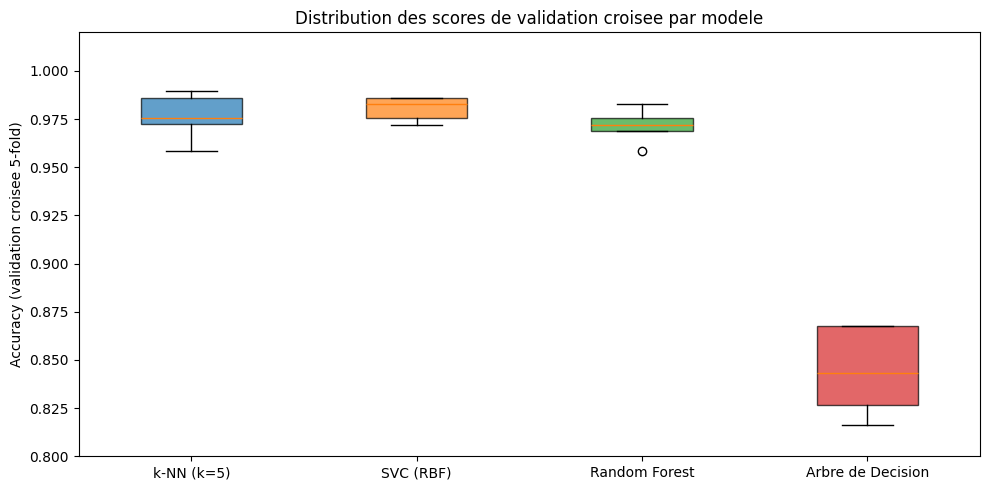

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
noms = list(cv_scores.keys())
data = [cv_scores[n] for n in noms]
bp = ax.boxplot(data, labels=noms, patch_artist=True)
colors = sns.color_palette('tab10', len(noms))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Accuracy (validation croisee 5-fold)')
ax.set_title('Distribution des scores de validation croisee par modele')
ax.set_ylim(0.8, 1.02)
plt.tight_layout()
plt.show()

---
## 6. Optimisation des Hyperparamètres (GridSearchCV)

Un hyperparamètre est une valeur fixée avant l'entraînement qui contrôle le comportement du modèle, par opposition aux paramètres (comme les poids) qui sont appris automatiquement pendant l'entraînement. Par exemple, pour le k-NN, `k` (le nombre de voisins) est un hyperparamètre : le modèle ne peut pas le choisir lui-même.

Le `GridSearchCV` teste toutes les combinaisons possibles d'hyperparamètres définies dans une grille, en évaluant chaque combinaison par validation croisée. Il retourne automatiquement la combinaison qui donne la meilleure performance moyenne sur les plis de validation.

On utilise des `Pipeline` pour enchaîner proprement le prétraitement et le classifieur. Cela garantit que la normalisation et l'ACP sont recalculées à chaque pli de la validation croisée, sans fuite d'information.

### 6.1 GridSearch sur k-NN (avec ACP)

In [25]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA()),
    ('knn',    KNeighborsClassifier())
])

knn_param_grid = {
    'pca__n_components': [15, 20, 25, 30, 40],   # nombre de composantes ACP
    'knn__n_neighbors':  [3, 5, 7, 9, 11],        # nombre de voisins
    'knn__weights':      ['uniform', 'distance']  # vote uniforme ou pondere par distance
}

print(f"Nombre de combinaisons : {5*5*2} x 5-fold = {5*5*2*5} evaluations")

gs_knn = GridSearchCV(
    knn_pipeline, knn_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_knn.fit(X_train, y_train)

print(f"\nMeilleurs parametres : {gs_knn.best_params_}")
print(f"Meilleur score CV    : {gs_knn.best_score_*100:.2f}%")
print(f"Accuracy sur test    : {gs_knn.score(X_test, y_test)*100:.2f}%")

Nombre de combinaisons : 50 x 5-fold = 250 evaluations

Meilleurs parametres : {'knn__n_neighbors': 7, 'knn__weights': 'distance', 'pca__n_components': 30}
Meilleur score CV    : 97.42%
Accuracy sur test    : 96.39%


### 6.2 GridSearch sur SVC (avec ACP)

In [26]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA()),
    ('svc',    SVC(random_state=RANDOM_STATE))
])

svc_param_grid = {
    'pca__n_components': [20, 30, 40],              # nombre de composantes ACP
    'svc__C':            [0.1, 1, 10, 100],          # regularisation
    'svc__gamma':        ['scale', 'auto'],           # influence de chaque point
    'svc__kernel':       ['rbf', 'poly']              # type de noyau
}

n_combi = 3 * 4 * 2 * 2
print(f"Nombre de combinaisons : {n_combi} x 5-fold = {n_combi*5} evaluations")

gs_svc = GridSearchCV(
    svc_pipeline, svc_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_svc.fit(X_train, y_train)

print(f"\nMeilleurs parametres : {gs_svc.best_params_}")
print(f"Meilleur score CV    : {gs_svc.best_score_*100:.2f}%")
print(f"Accuracy sur test    : {gs_svc.score(X_test, y_test)*100:.2f}%")

Nombre de combinaisons : 48 x 5-fold = 240 evaluations

Meilleurs parametres : {'pca__n_components': 40, 'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
Meilleur score CV    : 98.47%
Accuracy sur test    : 99.17%


### 6.3 GridSearch sur Random Forest

In [27]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    'rf__n_estimators':      [50, 100, 200],    # nombre d'arbres
    'rf__max_depth':         [None, 10, 20],    # profondeur maximale des arbres
    'rf__min_samples_split': [2, 5]             # minimum d'exemples pour diviser un noeud
}

n_combi = 3 * 3 * 2
print(f"Nombre de combinaisons : {n_combi} x 5-fold = {n_combi*5} evaluations")

gs_rf = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print(f"\nMeilleurs parametres : {gs_rf.best_params_}")
print(f"Meilleur score CV    : {gs_rf.best_score_*100:.2f}%")
print(f"Accuracy sur test    : {gs_rf.score(X_test, y_test)*100:.2f}%")

Nombre de combinaisons : 18 x 5-fold = 90 evaluations

Meilleurs parametres : {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Meilleur score CV    : 97.63%
Accuracy sur test    : 96.11%


### 6.4 Classement Final

Classement final :
                                 Modele      CV    Test
1       SVC optimise (ACP + GridSearch)  0.9847  0.9917
2            SVC de base (pixels bruts)  0.9805  0.9750
3      k-NN optimise (ACP + GridSearch)  0.9742  0.9639
4           k-NN de base (pixels bruts)  0.9763  0.9639
5  Random Forest de base (pixels bruts)  0.9715  0.9639
6   Random Forest optimise (GridSearch)  0.9763  0.9611
7             Arbre de Decision de base  0.8442  0.8167


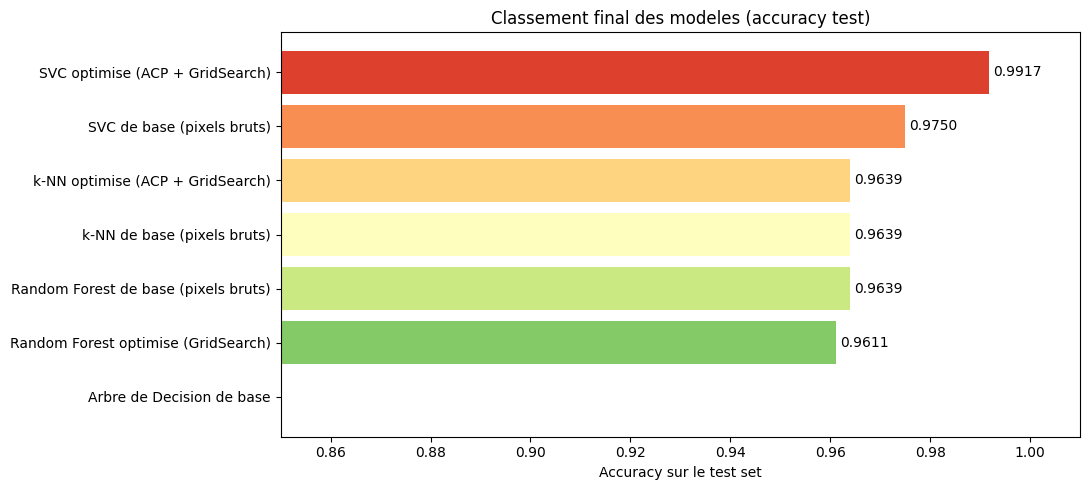

In [28]:
resultats_finaux = [
    {'Modele': 'k-NN optimise (ACP + GridSearch)',     'CV': gs_knn.best_score_, 'Test': gs_knn.score(X_test, y_test)},
    {'Modele': 'SVC optimise (ACP + GridSearch)',      'CV': gs_svc.best_score_, 'Test': gs_svc.score(X_test, y_test)},
    {'Modele': 'Random Forest optimise (GridSearch)',  'CV': gs_rf.best_score_,  'Test': gs_rf.score(X_test, y_test)},
    {'Modele': 'SVC de base (pixels bruts)',           'CV': cv_scores['SVC (RBF)'].mean(),       'Test': r_svc_raw['test']},
    {'Modele': 'Random Forest de base (pixels bruts)', 'CV': cv_scores['Random Forest'].mean(),   'Test': r_rf_raw['test']},
    {'Modele': 'k-NN de base (pixels bruts)',          'CV': cv_scores['k-NN (k=5)'].mean(),      'Test': r_knn_raw['test']},
    {'Modele': 'Arbre de Decision de base',            'CV': cv_scores['Arbre de Decision'].mean(),'Test': r_dt_raw['test']},
]

df_final = pd.DataFrame(resultats_finaux)
df_final['CV']   = df_final['CV'].round(4)
df_final['Test'] = df_final['Test'].round(4)
df_final = df_final.sort_values('Test', ascending=False).reset_index(drop=True)
df_final.index += 1
print("Classement final :")
print(df_final.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_final['Modele'][::-1], df_final['Test'][::-1],
               color=sns.color_palette('RdYlGn', len(df_final))[::-1])
ax.set_xlabel('Accuracy sur le test set')
ax.set_title('Classement final des modeles (accuracy test)')
ax.set_xlim(0.85, 1.01)
ax.bar_label(bars, fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()

---
## 7. Conclusion

**ACP vs pixels bruts** : La réduction de dimension par ACP améliore les performances du k-NN en réduisant la malédiction de la dimensionnalité (en haute dimension, les distances euclidiennes deviennent moins discriminantes). En revanche, pour le SVC et le Random Forest, l'apport de l'ACP est plus limité : ces modèles gèrent naturellement mieux les espaces de haute dimension.

**Comparaison des modèles** : Le SVC avec noyau RBF est généralement le plus performant sur ce type de données, atteignant une accuracy proche de 98-99% après optimisation. Le Random Forest donne des résultats solides avec peu de réglage. L'arbre de décision seul sur-apprend fortement (accuracy train de 1.0 contre une accuracy test bien inférieure), ce qui illustre directement l'intérêt d'agréger plusieurs arbres dans un Random Forest.

**GridSearchCV** : L'optimisation automatique a permis d'améliorer de façon systématique les performances de chaque modèle. Elle montre aussi que le choix des hyperparamètres a un impact significatif sur les résultats, et qu'il vaut mieux les sélectionner par validation croisée plutôt qu'à la main.

**Robustesse** : La validation croisée 5-fold confirme la stabilité des modèles. Les intervalles de confiance étroits indiquent que les performances mesurées ne sont pas dues à un split favorable, mais reflètent bien la capacité réelle de chaque modèle à généraliser.

**Pistes d'amélioration** :
- Tester sur le dataset MNIST (70 000 images) pour une évaluation à plus grande échelle
- Explorer des méthodes d'augmentation de données (rotations légères, translations)
- Essayer des réseaux de neurones convolutifs (CNN) qui exploitent la structure spatiale 2D des images plutôt que de traiter les pixels comme des features indépendantes